In [330]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [331]:
df=pd.read_csv('data.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [332]:
df.shape

(569, 33)

In [333]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

- No null values

In [334]:
df.drop("Unnamed: 32",axis=1,inplace=True)

In [335]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [336]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
df['diagnosis']=encoder.fit_transform(df['diagnosis'])

<ipython-input-337-e9083362156a>:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




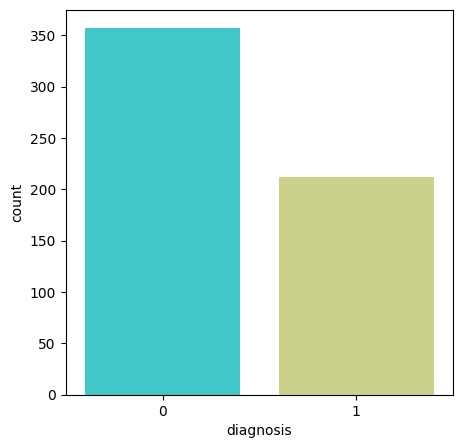

In [337]:
plt.figure(figsize=(5,5))
sns.countplot(x='diagnosis',data=df,palette='rainbow')
plt.show()

In [338]:
m_col = ['diagnosis','radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean']

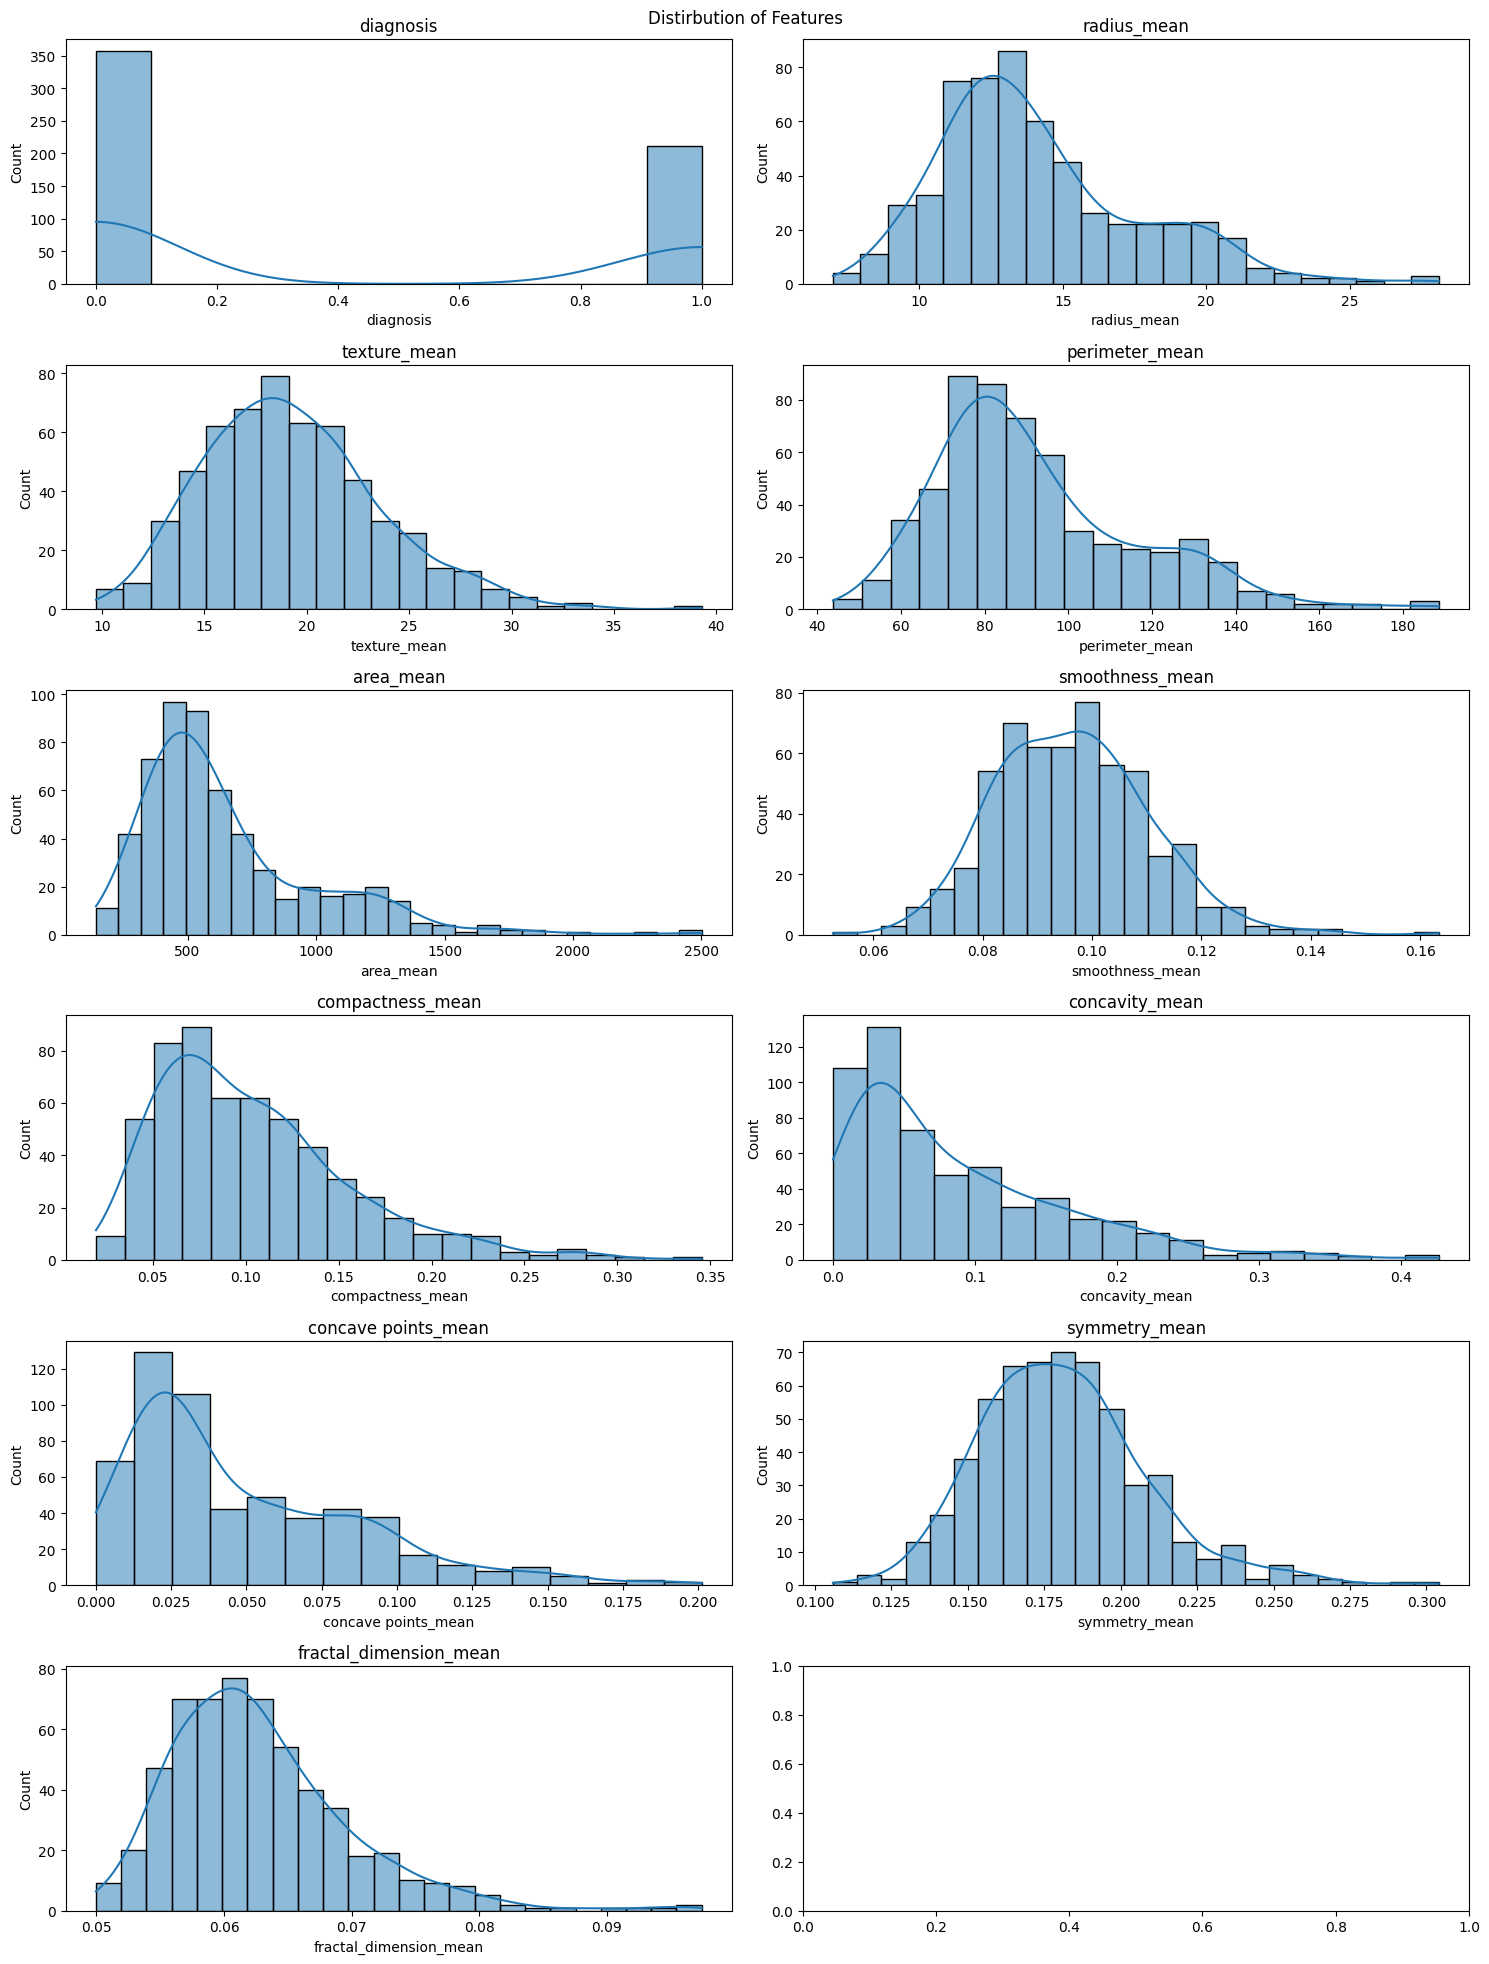

In [339]:
# Subplots for all features
fig , axs= plt.subplots(6,2,figsize=(15,20))
fig.suptitle('Distirbution of Features')

for i, feature in enumerate(m_col):
  row=i//2
  col=i%2
  #Hist
  sns.histplot(df[feature],kde=True,ax=axs[row,col])
  axs[row,col].set_title(feature)
  axs[row,col].set_ylabel('Count')
plt.tight_layout()
plt.show()

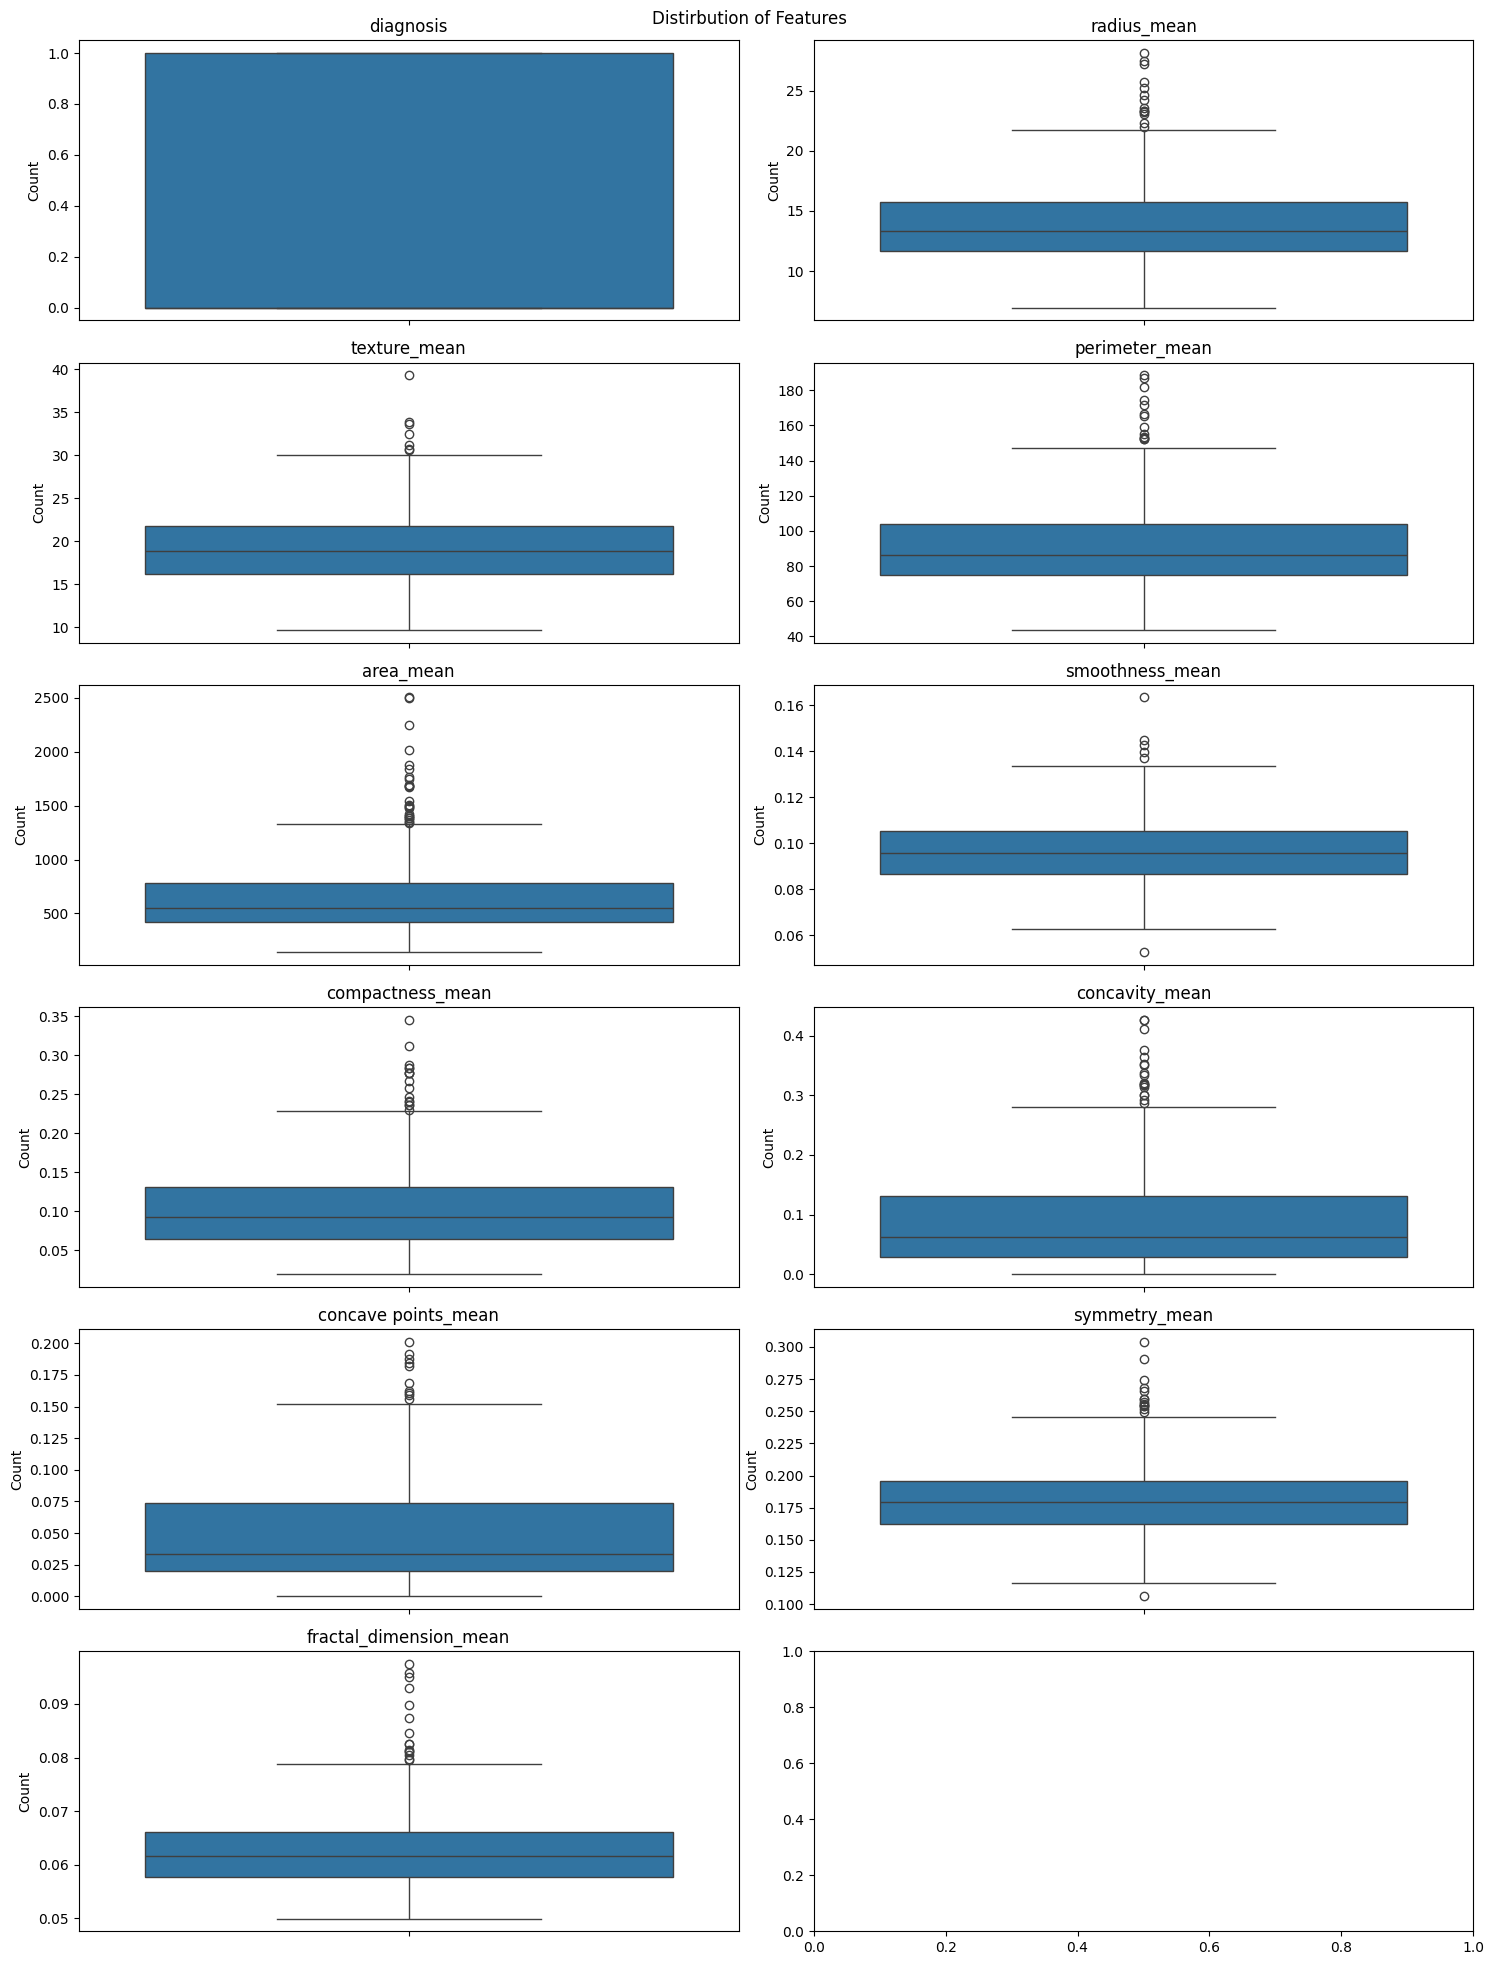

In [340]:
# Subplots for all features
fig , axs= plt.subplots(6,2,figsize=(15,20))
fig.suptitle('Distirbution of Features')

for i, feature in enumerate(m_col):
  row=i//2
  col=i%2
  #HBoxPlot
  sns.boxplot(df[feature],ax=axs[row,col])
  axs[row,col].set_title(feature)
  axs[row,col].set_ylabel('Count')
plt.tight_layout()
plt.show()

# <b>Text Pre-processing </b>




In [341]:
df['diagnosis'].value_counts()

,count
diagnosis,
0,357
1,212


**1 - M** <br>
**0 - B**

In [342]:
X=df.drop('diagnosis',axis=1)
y=df['diagnosis']

In [343]:
y.value_counts()

,count
diagnosis,
0,357
1,212


In [344]:
X_train,X_test, y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [345]:
from sklearn.model_selection import train_test_split

X_train,X_test, y_train, y_test=train_test_split(df.drop('diagnosis',axis=1),df['diagnosis'],test_size=0.2,random_state=42)

In [346]:
p=len(df.columns)
print(p)# Number of Features
n=len(df)
print(n)# Number of observation

32
569


In [347]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(455, 31)
(114, 31)
(455,)
(114,)


In [348]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.fit_transform(X_test)

In [349]:
from sklearn.linear_model import LogisticRegression


logistic_model=LogisticRegression()
logistic_model.fit(X_train,y_train)

logistic_model_result=logistic_model.predict(X_test)
logistic_model_accuracy=accuracy_score(y_test,logistic_model_result)

print("========Classification Report==========")
print(classification_report(y_test,logistic_model_result))
print("========Confusion Matrix==========")
print(confusion_matrix(y_test,logistic_model_result))

r_squared=r2_score(y_test,logistic_model_result)
logistic_adjusted_r2_score=1-(1-r_squared)*(n-1)/(n-p-1)
print("=================================")
print("Adjusted R Square: ",logistic_adjusted_r2_score)

========Classification Report==========
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        71
           1       1.00      0.95      0.98        43

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

========Confusion Matrix==========
[[71  0]
 [ 2 41]]
Adjusted R Square:  0.9208608122179798


In [350]:
from sklearn.svm import SVC
from sklearn.metrics import r2_score
from sklearn.metrics import classification_report,confusion_matrix


svc_model=SVC(kernel='rbf')
svc_model.fit(X_train,y_train)
svc_result=svc_model.predict(X_test)
svc_model_accuracy=accuracy_score(y_test,svc_result)

print("========Classification Report==========")
print(classification_report(y_test,svc_result))
print("========Confusion Matrix==========")
print(confusion_matrix(y_test,svc_result))

r_squared=r2_score(y_test,svc_result)
logistic_adjusted_r2_score=1-(1-r_squared)*(n-1)/(n-p-1)
print("=================================")
print("Adjusted R Square: ",logistic_adjusted_r2_score)

========Classification Report==========
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        71
           1       1.00      0.95      0.98        43

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

========Confusion Matrix==========
[[71  0]
 [ 2 41]]
Adjusted R Square:  0.9208608122179798


In [351]:
from sklearn.neighbors import KNeighborsClassifier

err=[]

for i in range(1,42):
  knn_classifier=KNeighborsClassifier(n_neighbors=i)
  knn_classifier.fit(X_train,y_train)
  pred_i=knn_classifier.predict(X_test)
  err.append(np.mean(pred_i!=y_test))

Text(0.5, 1.0, 'Error Rate K Value')

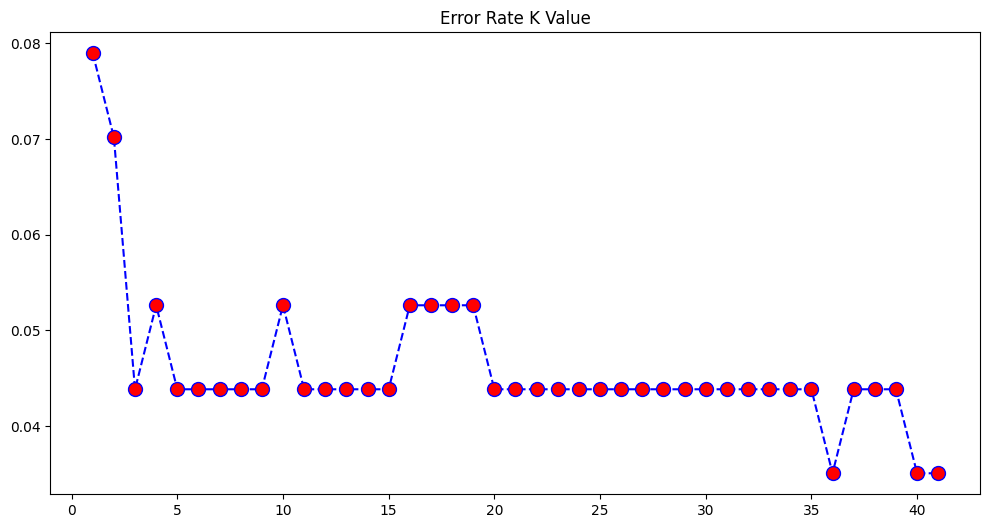

In [352]:
plt.figure(figsize=(12,6))
plt.plot(range(1,42),err,color='blue',linestyle='dashed',marker='o',markerfacecolor='red',markersize=10)
plt.title('Error Rate K Value')

In [353]:
knn_classifier=KNeighborsClassifier(n_neighbors=40)
knn_classifier.fit(X_train,y_train)
knn_model_result=knn_classifier.predict(X_test)
knn_model_accuracy=accuracy_score(y_test,knn_model_result)

print("========Classification Report==========")
print(classification_report(y_test,knn_model_result))
print("========Confusion Matrix==========")
print(confusion_matrix(y_test,knn_model_result))

r_squared=r2_score(y_test,knn_model_result)
knn_model_result=1-(1-r_squared)*(n-1)/(n-p-1)
print("=================================")
print("Adjusted R Square: ",knn_model_result)

========Classification Report==========
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        71
           1       1.00      0.91      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114

========Confusion Matrix==========
[[71  0]
 [ 4 39]]
Adjusted R Square:  0.8417216244359598


In [354]:
from sklearn.ensemble import RandomForestClassifier
random_forest_classifier=RandomForestClassifier(n_estimators=100)
random_forest_classifier.fit(X_train,y_train)
random_forest_result=random_forest_classifier.predict(X_test)
random_forest_accuracy=accuracy_score(y_test,random_forest_result)

print("========Classification Report==========")
print(classification_report(y_test,random_forest_result))
print("========Confusion Matrix==========")
print(confusion_matrix(y_test,random_forest_result))

r_squared=r2_score(y_test,random_forest_result)
random_forest_result=1-(1-r_squared)*(n-1)/(n-p-1)
print("=================================")
print("Adjusted R Square: ",random_forest_result)


========Classification Report==========
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        71
           1       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

========Confusion Matrix==========
[[70  1]
 [ 3 40]]
Adjusted R Square:  0.8417216244359598


In [355]:
from sklearn.ensemble import GradientBoostingClassifier
gradient_boosting_classifier=GradientBoostingClassifier()
gradient_boosting_classifier.fit(X_train,y_train)
gradient_boosting_result=gradient_boosting_classifier.predict(X_test)
gradient_boosting_accuracy=accuracy_score(y_test,gradient_boosting_result)

print("========Classification Report==========")
print(classification_report(y_test,gradient_boosting_result))
print("========Confusion Matrix==========")
print(confusion_matrix(y_test,gradient_boosting_result))

r_squared=r2_score(y_test,gradient_boosting_result)
gradient_boosting_result=1-(1-r_squared)*(n-1)/(n-p-1)
print("=================================")

print("Adjusted R Square: ",gradient_boosting_result)

========Classification Report==========
              precision    recall  f1-score   support

           0       0.95      0.97      0.96        71
           1       0.95      0.91      0.93        43

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114

========Confusion Matrix==========
[[69  2]
 [ 4 39]]
Adjusted R Square:  0.7625824366539395


In [356]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier


params={
    'learning_rate':[0.05,0.1,0.4],
    'max_depth':[3,5,10],
    "n_estimators":[100,200,500],
    'gamma':[0.01,0.1,1],
    'subsample':[0.5,0.7,1]
}

xgb_classifier=XGBClassifier(objective='binary:logistic')
grid_search=GridSearchCV(estimator=xgb_classifier,param_grid=params,scoring='accuracy')
grid_search.fit(X_train,y_train)

best_model=grid_search.best_estimator_
print(best_model)

xgb_classifier.fit(X_train,y_train)
xgb_result=best_model.predict(X_test)

xgb_classifier_accuracy=accuracy_score(y_test,xgb_result)

print("========Classification Report==========")
print(classification_report(y_test,xgb_result))
print("========Confusion Matrix==========")
print(confusion_matrix(y_test,xgb_result))

r_squared=r2_score(y_test,xgb_result)
xgb_result=1-(1-r_squared)*(n-1)/(n-p-1)
print("=================================")
print("Adjusted R Square: ",xgb_result)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=0.01, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.4, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)
========Classification Report==========
              precision    recall  f1-score   support

           0       0.97      0.99      0.98        71
           1       0.98      0.95      0.96        43

    accuracy                           0.97

/usr/local/lib/python3.10/dist-packages/numpy/ma/core.py:2820: RuntimeWarning:

invalid value encountered in cast



In [360]:
from sklearn.ensemble import StackingClassifier # Import StackingClassifier

base_models=[
    ('random_forest',random_forest_classifier),
    ('logistic_regression',logistic_model),
    ('svc',svc_model),
   # ('xgboost',xgb_classifier),
    #('gradient_boosting',grad_model)
]
stacking_reg=StackingClassifier(estimators=base_models,final_estimator=logistic_model) # Use StackingClassifier instead of StackingRegressor

stacking_reg.fit(X_train,y_train)
stacking_reg_result=stacking_reg.predict(X_test)

r2_stack=r2_score(y_test,stacking_reg_result)
adjusted_r2_stack=1-((1-r2_stack)*(731-1)/(731-9-1))
stacking_red_accuracy=accuracy_score(y_test,stacking_reg_result)
stacking_red_accuracy=accuracy_score(y_test,stacking_reg_result)

print("========Classification Report==========")
print(classification_report(y_test,stacking_reg_result))
print("========Confusion Matrix==========")
print(confusion_matrix(y_test,stacking_reg_result))
print("=================================")

print("R-squared: ",r2_stack)
print("Adjusted R2 Score: ",adjusted_r2_stack)

========Classification Report==========
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        71
           1       1.00      0.95      0.98        43

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

========Confusion Matrix==========
[[71  0]
 [ 2 41]]
R-squared:  0.9253193580085162
Adjusted R2 Score:  0.9243871447242952


In [361]:
accuracy_list=[svc_model_accuracy,
            logistic_model_accuracy,
            knn_model_accuracy,
            random_forest_accuracy,
            gradient_boosting_accuracy,
            xgb_classifier_accuracy,
            stacking_red_accuracy]
model_list=['SVC',
            'Logistic',
            'Knn',
            'Random Forest',
            'Gradient Boost',
            'XGB',
            'Stacking Reg']

In [362]:
import plotly.express as px
df=pd.DataFrame({'Model':model_list,'Accuracy':accuracy_list})

fig=px.bar(df,x='Model',y='Accuracy',color='Accuracy',title='Model Accuracy')
fig.update_layout(xaxis_title='Accuracy',yaxis_title='Model')
fig.show()

In [365]:
import joblib

joblib.dump(stacking_reg,'stacking_regressor.pkl')

['stacking_regressor.pkl']